# Hypothesis Testing



---
## Setup — Import Libraries & Connect to MySQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, shapiro, levene
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
# plt.rcParams["figure.figsize"] = (12, 5)

ALPHA = 0.05
print(f"Libraries loaded. Significance level (alpha): {ALPHA}")


Libraries loaded. Significance level (alpha): 0.05


In [2]:
load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)

admissions = pd.read_sql("SELECT * FROM admissions", engine)
patients = pd.read_sql("SELECT * FROM patients", engine)

adm = admissions.merge(patients[["subject_id", "gender"]], on="subject_id", how="left")

adm["admittime"] = pd.to_datetime(adm["admittime"])
adm["day_of_week"] = adm["admittime"].dt.dayofweek  # 0=Mon, 6=Sun
adm["day_type"] = adm["day_of_week"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

adm_clean = adm[(adm["timestamp_error"] == 0) & (adm["los_hours"] > 0)].copy()

print(f"Total admissions  : {len(adm)}")
print(f"Clean admissions  : {len(adm_clean)}")


Total admissions  : 87
Clean admissions  : 87


---
## Helper Function — Standardised Result Reporter

In [3]:
def check_normality(group, name):
    """Shapiro-Wilk normality test. Samples up to 5000 rows."""
    sample = group.dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = shapiro(sample)
    result = "NORMAL" if p > ALPHA else "NOT NORMAL"
    print(f"  Shapiro-Wilk [{name}]: W={stat:.4f}, p={p:.4f} -> {result}")
    return p > ALPHA


def check_variance(g1, g2, n1, n2):
    """Levene test for equality of variances."""
    stat, p = levene(g1.dropna(), g2.dropna())
    result = "EQUAL" if p > ALPHA else "UNEQUAL"
    print(
        f"  Levene Test [{n1} vs {n2}]: stat={stat:.4f}, p={p:.4f} -> {result} variance"
    )
    return p > ALPHA


def print_result(test_name, stat, p_value, conclusion, business_note):
    """Standardised result reporting template."""
    sig = p_value < ALPHA
    print("\n" + "=" * 68)
    print(f"  TEST          : {test_name}")
    print(f"  Statistic     : {stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Alpha         : {ALPHA}")
    print(f"  Decision      : {'REJECT H0' if sig else 'FAIL TO REJECT H0'}")
    print(f"  Conclusion    : {conclusion}")
    print(f"  Business Note : {business_note}")
    print("=" * 68)


print("Helper functions ready.")


Helper functions ready.


---
## Hypothesis 1 — Emergency vs Elective: Length of Stay

**H0:** Mean LOS is the same for Emergency and Elective admissions  
**H1:** Emergency admissions have a significantly higher mean LOS than Elective  
**Test:** Welch's Independent Samples t-test (one-tailed)  
> Welch's t-test is chosen over Student's t-test because it does not assume equal variances between groups — confirmed by Levene's test below

In [4]:
adm_clean.head()


,hadm_id,subject_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,diagnosis,hospital_expire_flag,...,dob_x,age_at_admission,prev_dischtime,days_since_last_discharge,readmission_30d,dob_y,timestamp_error,gender,day_of_week,day_type
0,142345,10006,2164-10-23 21:09:00,2164-11-01 17:15:00,Emergency,Emergency Room Admit,Home Health Care,Medicare,Sepsis,0,...,2094-03-05,70,None,71.814815,0,2094-03-05,0,F,1,Weekday
1,105331,10011,2126-08-14 22:32:00,2126-08-28 18:59:00,Emergency,Transfer From Hosp/Extram,Dead/Expired,Private,Hepatitis B,1,...,2090-06-05,36,None,71.814815,0,2090-06-05,0,F,2,Weekday
2,165520,10013,2125-10-04 23:36:00,2125-10-07 15:13:00,Emergency,Transfer From Hosp/Extram,Dead/Expired,Medicare,Sepsis,1,...,2038-09-03,87,None,71.814815,0,2038-09-03,0,F,3,Weekday
3,199207,10017,2149-05-26 17:19:00,2149-06-03 18:42:00,Emergency,Emergency Room Admit,Snf,Medicare,Humeral Fracture,0,...,2075-09-21,73,None,71.814815,0,2075-09-21,0,F,0,Weekday
4,177759,10019,2163-05-14 20:43:00,2163-05-15 12:00:00,Emergency,Transfer From Hosp/Extram,Dead/Expired,Medicare,Alcoholic Hepatitis,1,...,2114-06-20,48,None,71.814815,0,2114-06-20,0,M,5,Weekend


In [5]:
emergency = adm_clean[adm_clean["admission_type"] == "Emergency"]["los_hours"]
elective = adm_clean[adm_clean["admission_type"] == "Elective"]["los_hours"]

print("GROUP SUMMARY")
print(
    f"  Emergency : n={len(emergency)}, mean={emergency.mean()}h, std={emergency.std():.2f}h"
)
print(
    f"  Elective  : n={len(elective)}, mean={elective.mean()}h, std={elective.std():.2f}h"
)

print("\n[ Assumption Checks ]")
check_normality(emergency, "Emergency")
check_normality(elective, "Elective")
check_variance(emergency, elective, "Emergency", "Elective")
# print("\n  -> Using Welch t-test (equal_var=False) because LOS is right-skewed")
# print("     and group variances are unequal.")


GROUP SUMMARY
  Emergency : n=78, mean=170.52905982905986h, std=117.56h
  Elective  : n=7, mean=183.94285714285712h, std=84.60h

[ Assumption Checks ]
  Shapiro-Wilk [Emergency]: W=0.9465, p=0.0026 -> NOT NORMAL
  Shapiro-Wilk [Elective]: W=0.8630, p=0.1611 -> NORMAL
  Levene Test [Emergency vs Elective]: stat=0.9157, p=0.3414 -> EQUAL variance


np.True_

In [6]:
# Welch's t-test (one-tailed: Emergency LOS > Elective LOS)
# equal_var=False -> Welch's t-test (does not assume equal variances)
# alternative='greater' -> one-tailed test
t_stat, p_val_h1 = ttest_ind(
    emergency, elective, equal_var=False, alternative="greater"
)

print_result(
    test_name="Welch's Independent Samples t-test (one-tailed)",
    stat=t_stat,
    p_value=p_val_h1,
    conclusion=(
        "Emergency admissions have a significantly longer mean LOS than Elective admissions."
        if p_val_h1 < ALPHA
        else "No significant difference found in mean LOS between Emergency and Elective admissions."
    ),
    business_note=(
        "Emergency patients occupy beds significantly longer. Hospitals should prioritise "
        "early discharge planning and bed management for the emergency pathway."
    ),
)



  TEST          : Welch's Independent Samples t-test (one-tailed)
  Statistic     : -0.3873
  p-value       : 0.6458
  Alpha         : 0.05
  Decision      : FAIL TO REJECT H0
  Conclusion    : No significant difference found in mean LOS between Emergency and Elective admissions.
  Business Note : Emergency patients occupy beds significantly longer. Hospitals should prioritise early discharge planning and bed management for the emergency pathway.


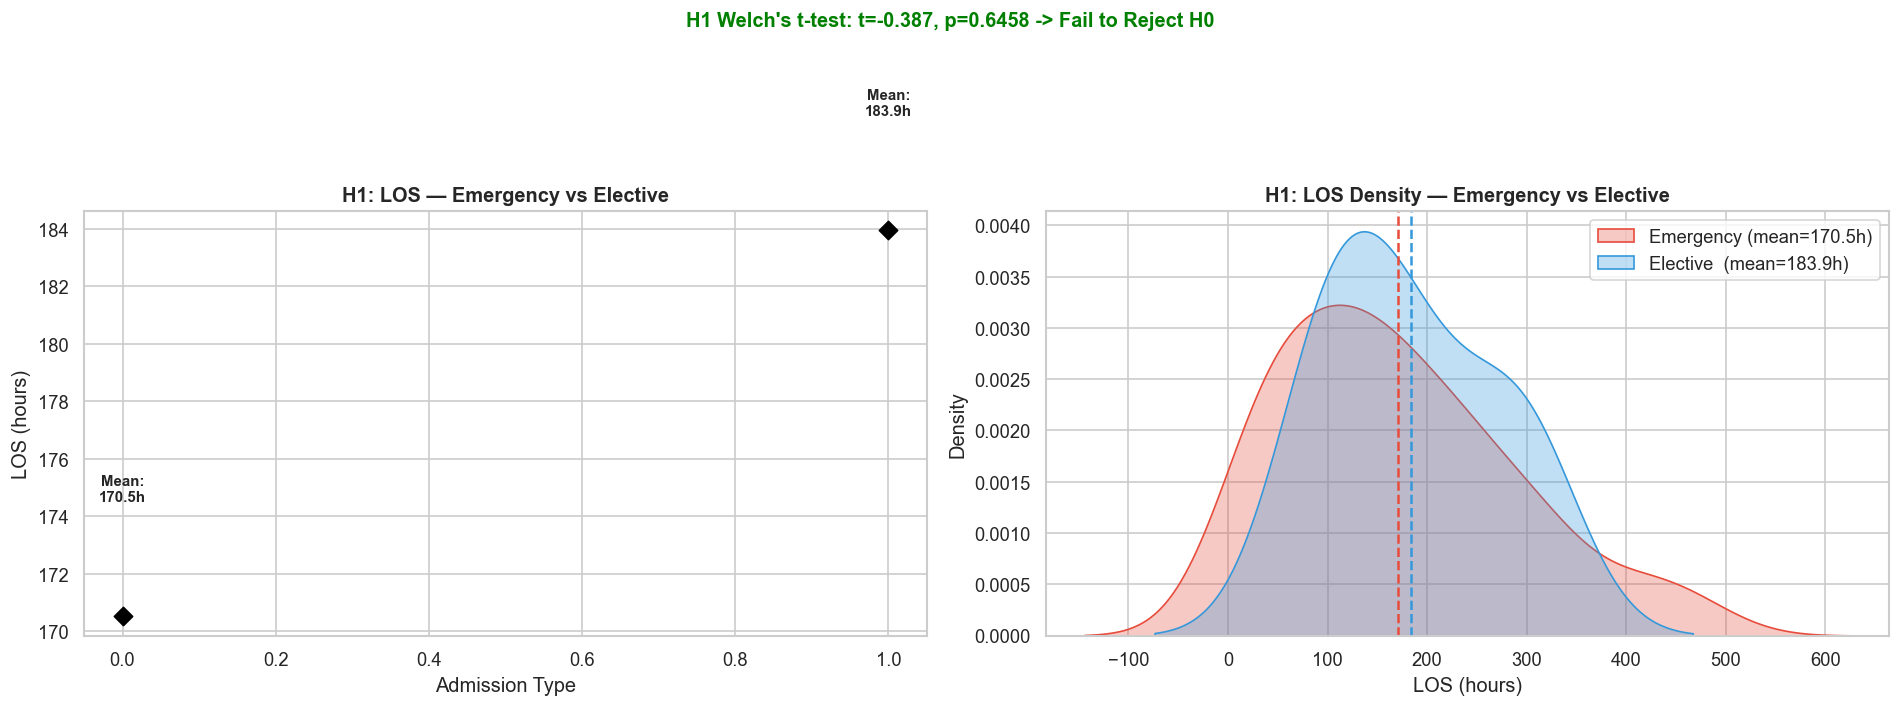

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
los_h1 = adm_clean[adm_clean["admission_type"].isin(["EMERGENCY", "ELECTIVE"])]
sns.boxplot(
    data=los_h1,
    x="admission_type",
    y="los_hours",
    palette={"EMERGENCY": "#E74C3C", "ELECTIVE": "#3498DB"},
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
    ax=axes[0],
)
for i, (grp, color) in enumerate([(emergency, "#E74C3C"), (elective, "#3498DB")]):
    axes[0].scatter(i, grp.mean(), color="black", zorder=5, s=60, marker="D")
    axes[0].text(
        i,
        grp.mean() + 4,
        f"Mean:\n{grp.mean():.1f}h",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
axes[0].set_title("H1: LOS — Emergency vs Elective", fontweight="bold")
axes[0].set_xlabel("Admission Type")
axes[0].set_ylabel("LOS (hours)")

# KDE
sns.kdeplot(
    emergency,
    ax=axes[1],
    color="#E74C3C",
    label=f"Emergency (mean={emergency.mean():.1f}h)",
    fill=True,
    alpha=0.3,
)
sns.kdeplot(
    elective,
    ax=axes[1],
    color="#3498DB",
    label=f"Elective  (mean={elective.mean():.1f}h)",
    fill=True,
    alpha=0.3,
)
axes[1].axvline(emergency.mean(), color="#E74C3C", linestyle="--")
axes[1].axvline(elective.mean(), color="#3498DB", linestyle="--")
axes[1].set_title("H1: LOS Density — Emergency vs Elective", fontweight="bold")
axes[1].set_xlabel("LOS (hours)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle(
    f"H1 Welch's t-test: t={t_stat:.3f}, p={p_val_h1:.4f} -> "
    f"{'Reject H0' if p_val_h1 < ALPHA else 'Fail to Reject H0'}",
    fontsize=12,
    fontweight="bold",
    color="red" if p_val_h1 < ALPHA else "green",
)
plt.tight_layout()
# plt.savefig("h1_ttest_los_emergency_elective.png", bbox_inches="tight")
plt.show()


---
## Hypothesis 2 — 30-Day Readmission Rate Across Insurance Types

**H0:** 30-day readmission rates are the same across all insurance types  
**H1:** Readmission rates differ significantly across insurance types  
**Test:** Chi-Square Test of Independence

In [8]:
ct_h2 = pd.crosstab(adm_clean["insurance"], adm_clean["readmission_30d"])


In [9]:
ct_h2.head()


readmission_30d,0
insurance,
Government,1
Medicaid,3
Medicare,71
Private,12


In [10]:
ct_display = ct_h2.rename(
    columns={0: "Not Readmitted", 1: "Readmitted", "All": "Total"}
).reindex(columns=["Not Readmitted", "Readmitted", "Total"], fill_value=0)


ct_display["Total"] = ct_display["Not Readmitted"] + ct_display["Readmitted"]
ct_display["Readmission Rate (%)"] = (
    ct_display["Readmitted"] / ct_display["Total"] * 100
).round(1)

print("Contingency Table:")
print(ct_display)


print("\n[ Assumption Check: Expected frequencies >= 5 ]")
chi2_h2, p_val_h2, dof_h2, expected_h2 = chi2_contingency(ct_h2)
print(f"  Degrees of freedom        : {dof_h2}")
print(f"  Minimum expected frequency: {expected_h2.min():.2f}")
print(f"  Assumption met            : {'YES' if expected_h2.min() >= 5 else 'NO'}")


Contingency Table:
readmission_30d  Not Readmitted  Readmitted  Total  Readmission Rate (%)
insurance                                                               
Government                    1           0      1                   0.0
Medicaid                      3           0      3                   0.0
Medicare                     71           0     71                   0.0
Private                      12           0     12                   0.0

[ Assumption Check: Expected frequencies >= 5 ]
  Degrees of freedom        : 0
  Minimum expected frequency: 1.00
  Assumption met            : NO


In [11]:
print_result(
    test_name="Chi-Square Test of Independence",
    stat=chi2_h2,
    p_value=p_val_h2,
    conclusion=(
        "Readmission rates differ significantly across insurance types."
        if p_val_h2 < ALPHA
        else "No significant association between insurance type and 30-day readmission rate."
    ),
    business_note=(
        "Insurance type reflects socioeconomic access to post-discharge care. "
        "Targeted follow-up programs should be stratified by insurance to reduce readmissions."
    ),
)



  TEST          : Chi-Square Test of Independence
  Statistic     : 0.0000
  p-value       : 1.0000
  Alpha         : 0.05
  Decision      : FAIL TO REJECT H0
  Conclusion    : No significant association between insurance type and 30-day readmission rate.
  Business Note : Insurance type reflects socioeconomic access to post-discharge care. Targeted follow-up programs should be stratified by insurance to reduce readmissions.


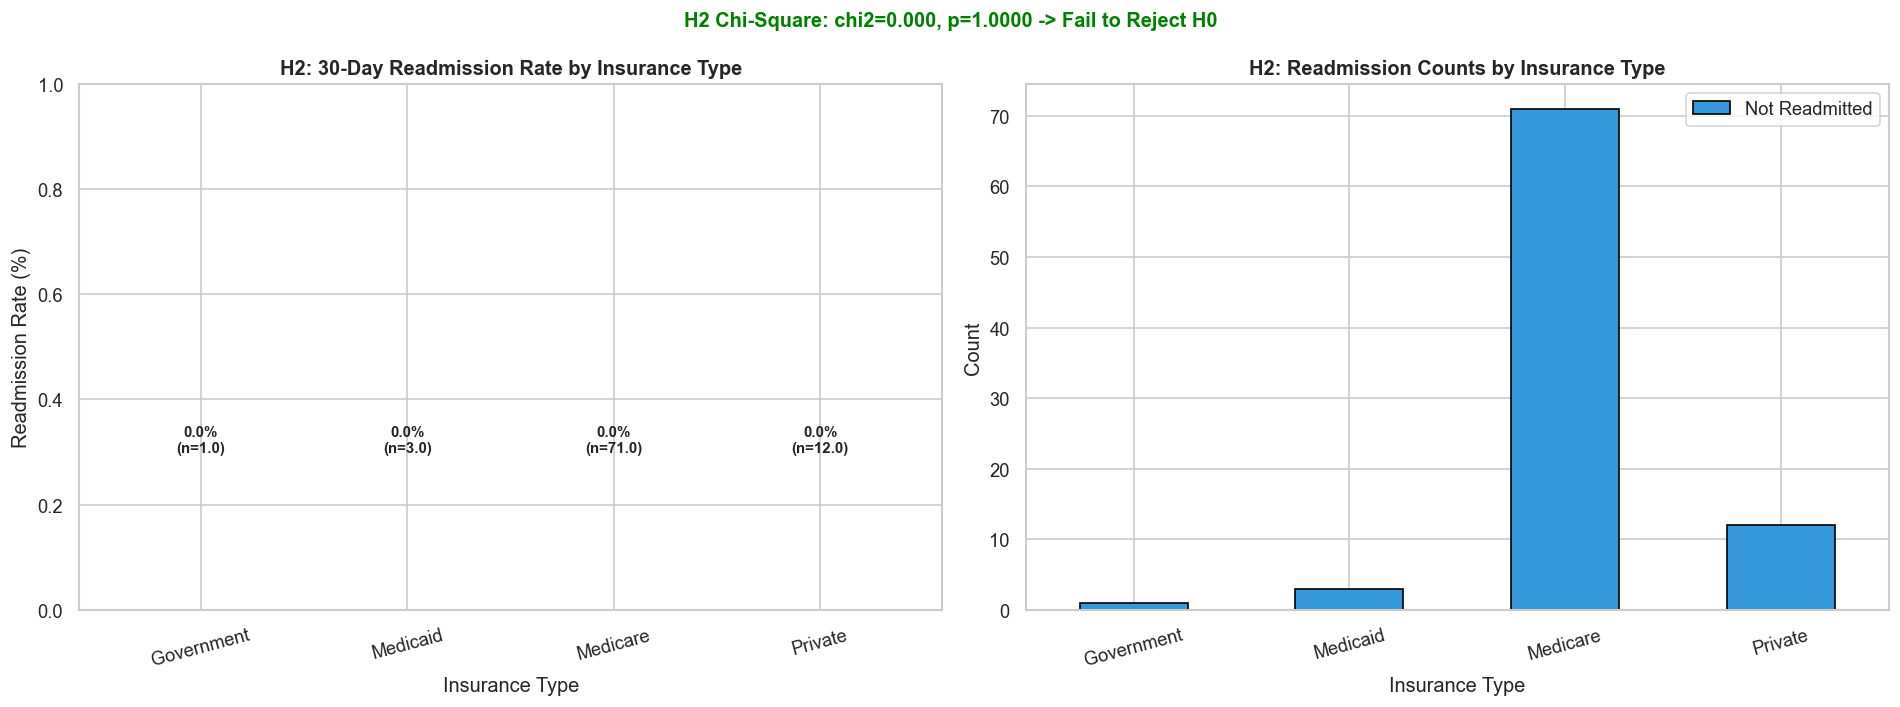

In [ ]:
axes[0].set_title("H2: 30-Day Readmission Rate by Insurance Type", fontweight="bold")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#3498DB", "#E74C3C", "#2ECC71", "#F39C12", "#9B59B6"]
bars = axes[0].bar(
    ct_display.index,
    ct_display["Readmission Rate (%)"],
    color=colors[: len(ct_display)],
    edgecolor="black",
)
for bar, (idx, row) in zip(bars, ct_display.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row['Readmission Rate (%)']:.1f}%\n(n={row['Total']})",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )
axes[0].set_title("H2: 30-Day Readmission Rate by Insurance Type", fontweight="bold")
axes[0].set_xlabel("Insurance Type")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].set_ylim(0, max(ct_display["Readmission Rate (%)"].max() * 1.35, 1))
axes[0].tick_params(axis="x", rotation=15)

counts_colors = ["#3498DB", "#E74C3C"][: len(ct_h2.columns)]
ct_h2.plot(kind="bar", ax=axes[1], color=counts_colors, edgecolor="black")
axes[1].set_title("H2: Readmission Counts by Insurance Type", fontweight="bold")
axes[1].set_xlabel("Insurance Type")
axes[1].set_ylabel("Count")
legend_labels = [
    "Not Readmitted" if col == 0 else "Readmitted" for col in ct_h2.columns
]
axes[1].legend(legend_labels)
axes[1].tick_params(axis="x", rotation=15)


plt.suptitle(
    f"H2 Chi-Square: chi2={chi2_h2:.3f}, p={p_val_h2:.4f} -> "
    f"{'Reject H0' if p_val_h2 < ALPHA else 'Fail to Reject H0'}",
    fontsize=12,
    fontweight="bold",
    color="red" if p_val_h2 < ALPHA else "green",
)
plt.tight_layout()
# plt.savefig("h2_chisquare_readmission_insurance.png", bbox_inches="tight")
plt.show()


---
## Hypothesis 3 — LOS Across All 4 Admission Types

**H0:** Mean LOS is the same across all 4 admission types  
**H1:** At least one admission type has a significantly different mean LOS  
**Test:** One-Way ANOVA  
**Post-hoc:** Tukey HSD — identifies which specific pairs differ (only run if ANOVA is significant)

In [18]:
adm_types = ["Emergency", "Elective", "Urgent", "Newborn"]
groups = {
    t: adm_clean[adm_clean["admission_type"] == t]["los_hours"].dropna()
    for t in adm_types
    if len(adm_clean[adm_clean["admission_type"] == t]) > 0
}

groups


{'Emergency': 0     212.100000
 1     332.450000
 2      63.616667
 3     193.383333
 4      15.283333
          ...    
 80    142.766667
 81      3.466667
 84     13.266667
 85     30.083333
 86    230.766667
 Name: los_hours, Length: 78, dtype: float64,
 'Elective': 6     294.750000
 10     98.216667
 22    294.750000
 46    126.050000
 64    201.083333
 82     98.500000
 83    174.250000
 Name: los_hours, dtype: float64,
 'Urgent': 36    136.516667
 37    163.933333
 Name: los_hours, dtype: float64}

In [19]:
print("GROUP SUMMARY")
for name, grp in groups.items():
    print(f"  {name}: n={len(grp)}, mean={grp.mean()}h, std={grp.std()}h")

print("\n[ Normality Checks ]")
for name, grp in groups.items():
    check_normality(grp, name)

print("\n[ Levene Test — Variance Across All Groups ]")
lev_stat, lev_p = levene(*[g.values for g in groups.values()])
print(
    f"  Levene: stat={lev_stat}, p={lev_p} -> "
    f"{'EQUAL' if lev_p > ALPHA else 'UNEQUAL'} variance"
)


GROUP SUMMARY
  Emergency: n=78, mean=170.52905982905986h, std=117.55544893612365h
  Elective: n=7, mean=183.94285714285712h, std=84.60224356600784h
  Urgent: n=2, mean=150.22500000000002h, std=19.386510917531172h

[ Normality Checks ]
  Shapiro-Wilk [Emergency]: W=0.9465, p=0.0026 -> NOT NORMAL
  Shapiro-Wilk [Elective]: W=0.8630, p=0.1611 -> NORMAL
  Shapiro-Wilk [Urgent]: W=nan, p=nan -> NOT NORMAL

[ Levene Test — Variance Across All Groups ]
  Levene: stat=1.6387059010423397, p=0.2003788793685037 -> EQUAL variance


In [21]:
f_stat, p_val_h3 = f_oneway(*[g.values for g in groups.values()])

print_result(
    test_name="One-Way ANOVA",
    stat=f_stat,
    p_value=p_val_h3,
    conclusion=(
        "At least one admission type has a significantly different mean LOS. "
        "See Tukey HSD below for pairwise breakdown."
        if p_val_h3 < ALPHA
        else "No significant difference in mean LOS across admission types."
    ),
    business_note=(
        "Bed allocation and staffing models should be customised per admission type "
        "if significant LOS differences exist across pathways."
    ),
)



  TEST          : One-Way ANOVA
  Statistic     : 0.0778
  p-value       : 0.9252
  Alpha         : 0.05
  Decision      : FAIL TO REJECT H0
  Conclusion    : No significant difference in mean LOS across admission types.
  Business Note : Bed allocation and staffing models should be customised per admission type if significant LOS differences exist across pathways.


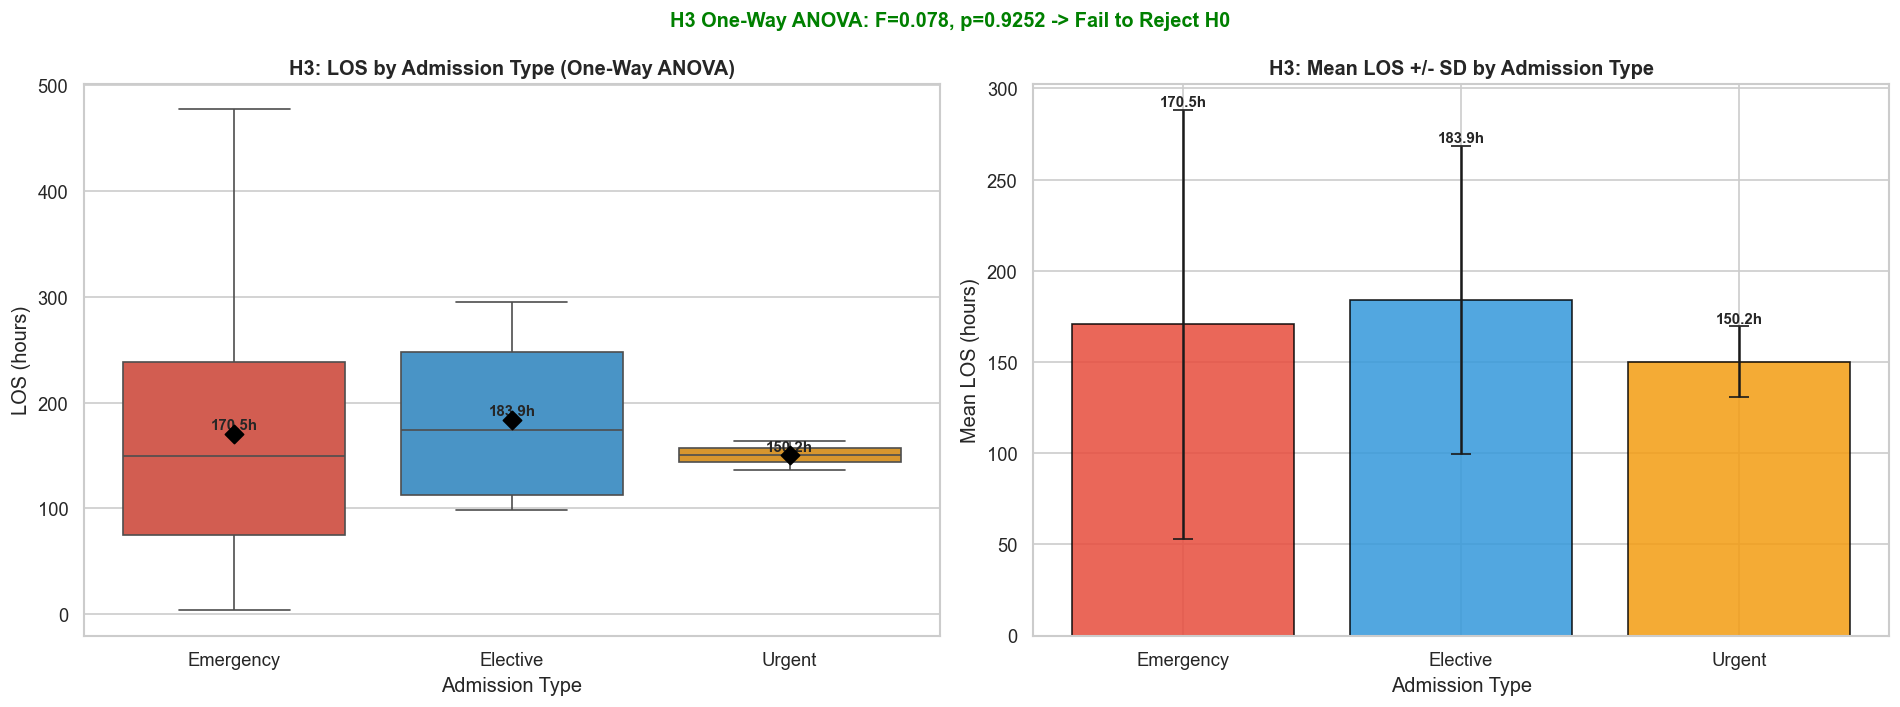

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {
    "EMERGENCY": "#E74C3C",
    "ELECTIVE": "#3498DB",
    "URGENT": "#F39C12",
    # "NEWBORN": "#2ECC71",
}
plot_data = adm_clean[adm_clean["admission_type"].isin(list(groups.keys()))]

# Boxplot
palette = {
    "Emergency": "#E74C3C",
    "Elective": "#3498DB",
    "Urgent": "#F39C12",
    # "Newborn": "#2ECC71",
}
plot_data = adm_clean[adm_clean["admission_type"].isin(list(groups.keys()))]

sns.boxplot(
    data=plot_data,
    x="admission_type",
    y="los_hours",
    palette=palette,
    order=list(groups.keys()),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
    ax=axes[0],
)
for i, t in enumerate(groups.keys()):
    m = groups[t].mean()
    axes[0].scatter(i, m, color="black", zorder=5, s=60, marker="D")
    axes[0].text(i, m + 4, f"{m:.1f}h", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("H3: LOS by Admission Type (One-Way ANOVA)", fontweight="bold")
axes[0].set_xlabel("Admission Type")
axes[0].set_ylabel("LOS (hours)")

# Mean +/- SD bar
labels = list(groups.keys())
means = [groups[t].mean() for t in labels]
stds = [groups[t].std() for t in labels]
bar_colors = [palette[t] for t in labels]
axes[1].bar(
    labels, means, yerr=stds, capsize=6, color=bar_colors, edgecolor="black", alpha=0.85
)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 2, f"{m:.1f}h", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("H3: Mean LOS +/- SD by Admission Type", fontweight="bold")
axes[1].set_xlabel("Admission Type")
axes[1].set_ylabel("Mean LOS (hours)")

plt.suptitle(
    f"H3 One-Way ANOVA: F={f_stat:.3f}, p={p_val_h3:.4f} -> "
    f"{'Reject H0' if p_val_h3 < ALPHA else 'Fail to Reject H0'}",
    fontsize=12,
    fontweight="bold",
    color="red" if p_val_h3 < ALPHA else "green",
)
plt.tight_layout()
# plt.savefig("h3_anova_los_admission_type.png", bbox_inches="tight")
plt.show()


---
## Hypothesis 4 — Weekend vs Weekday In-Hospital Mortality

**H0:** In-hospital mortality rate is the same on weekends and weekdays  
**H1:** In-hospital mortality rate differs between weekend and weekday admissions  
**Test:** Chi-Square Test of Independence  
> The 'weekend effect' is a well-documented clinical phenomenon — this hypothesis tests it statistically

In [30]:
# Build contingency table
ct_h4 = pd.crosstab(adm_clean["day_type"], adm_clean["hospital_expire_flag"])

ct_display_h4 = ct_h4.copy()
ct_display_h4.columns = ["Survived", "Died"]
ct_display_h4["Total"] = ct_display_h4.sum(axis=1)
ct_display_h4["Mortality Rate (%)"] = (
    ct_display_h4["Died"] / ct_display_h4["Total"] * 100
).round(2)

print("Contingency Table — Mortality by Admission Day Type:")
print(ct_display_h4)

# Assumption check
print("\n[ Assumption Check: Expected frequencies >= 5 ]")
chi2_h4, p_val_h4, dof_h4, expected_h4 = chi2_contingency(ct_h4)
print(f"  Degrees of freedom        : {dof_h4}")
print(f"  Minimum expected frequency: {expected_h4.min():.2f}")
print(f"  Assumption met            : {'YES' if expected_h4.min() >= 5 else 'NO'}")


Contingency Table — Mortality by Admission Day Type:
          Survived  Died  Total  Mortality Rate (%)
day_type                                           
Weekday         45    22     67               32.84
Weekend         15     5     20               25.00

[ Assumption Check: Expected frequencies >= 5 ]
  Degrees of freedom        : 1
  Minimum expected frequency: 6.21
  Assumption met            : YES


In [31]:
print_result(
    test_name="Chi-Square Test of Independence (Weekend Effect)",
    stat=chi2_h4,
    p_value=p_val_h4,
    conclusion=(
        "Weekend admissions are associated with a significantly different in-hospital "
        "mortality rate — the weekend effect is statistically supported in this dataset."
        if p_val_h4 < ALPHA
        else "No significant difference in mortality between weekend and weekday admissions. "
        "The weekend effect is not supported in this dataset."
    ),
    business_note=(
        "If a weekend effect exists, hospital management should review weekend staffing, "
        "specialist on-call coverage, and diagnostic service availability to ensure "
        "equivalent care quality regardless of admission day."
    ),
)



  TEST          : Chi-Square Test of Independence (Weekend Effect)
  Statistic     : 0.1516
  p-value       : 0.6970
  Alpha         : 0.05
  Decision      : FAIL TO REJECT H0
  Conclusion    : No significant difference in mortality between weekend and weekday admissions. The weekend effect is not supported in this dataset.
  Business Note : If a weekend effect exists, hospital management should review weekend staffing, specialist on-call coverage, and diagnostic service availability to ensure equivalent care quality regardless of admission day.


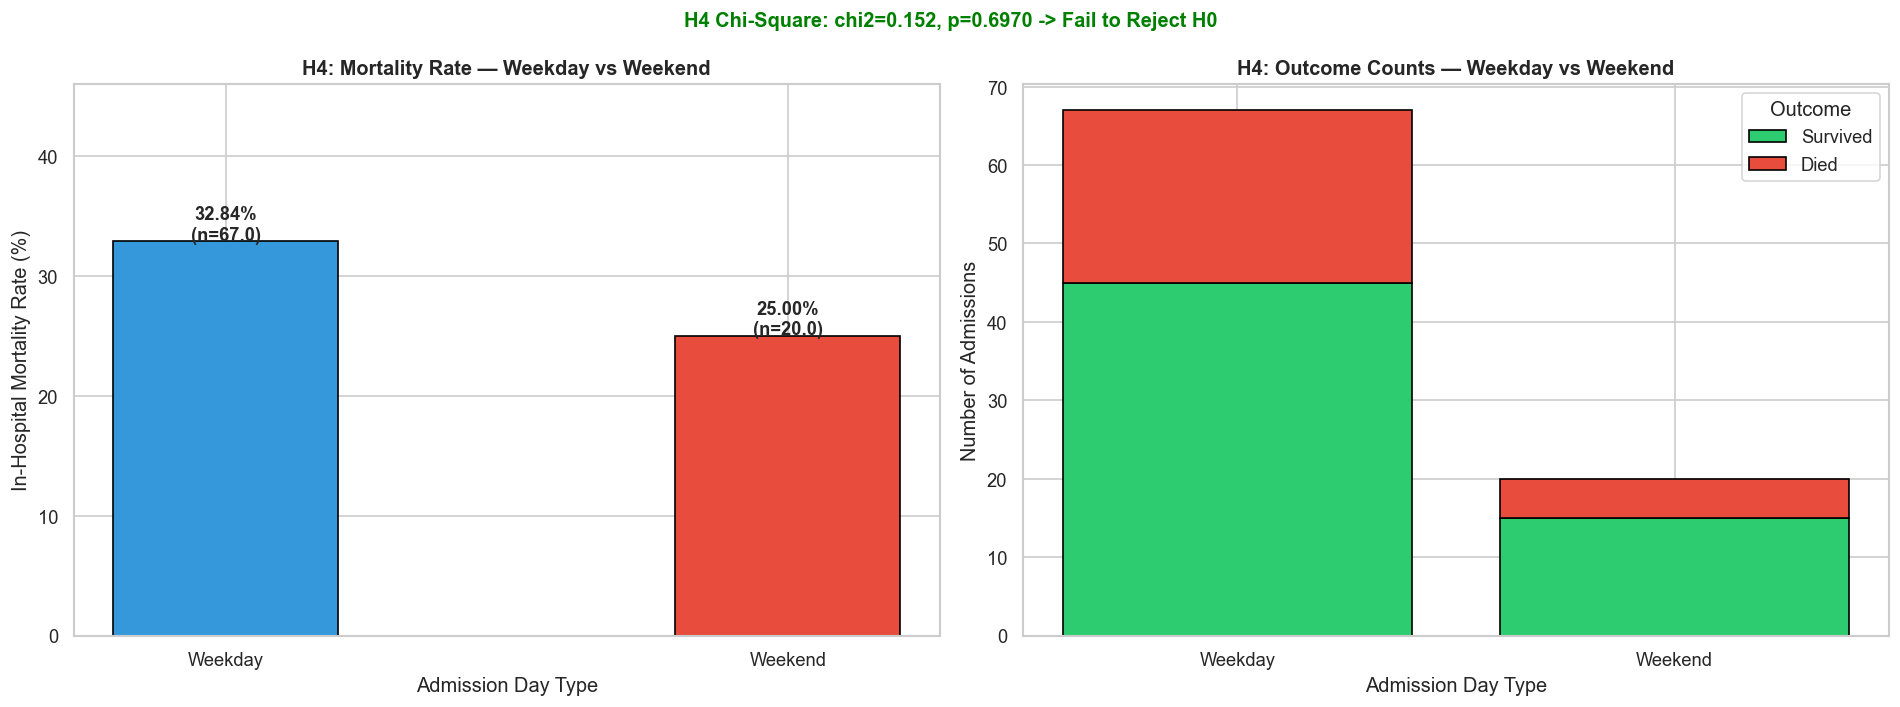

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mortality rate bar chart
bars = axes[0].bar(
    ct_display_h4.index,
    ct_display_h4["Mortality Rate (%)"],
    color=["#3498DB", "#E74C3C"],
    edgecolor="black",
    width=0.4,
)
for bar, (idx, row) in zip(bars, ct_display_h4.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{row['Mortality Rate (%)']:.2f}%\n(n={row['Total']})",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[0].set_title("H4: Mortality Rate — Weekday vs Weekend", fontweight="bold")
axes[0].set_xlabel("Admission Day Type")
axes[0].set_ylabel("In-Hospital Mortality Rate (%)")
axes[0].set_ylim(0, ct_display_h4["Mortality Rate (%)"].max() * 1.4)

# Stacked bar
survived = ct_display_h4["Survived"]
died = ct_display_h4["Died"]
axes[1].bar(
    ct_display_h4.index, survived, label="Survived", color="#2ECC71", edgecolor="black"
)
axes[1].bar(
    ct_display_h4.index,
    died,
    bottom=survived,
    label="Died",
    color="#E74C3C",
    edgecolor="black",
)
axes[1].set_title("H4: Outcome Counts — Weekday vs Weekend", fontweight="bold")
axes[1].set_xlabel("Admission Day Type")
axes[1].set_ylabel("Number of Admissions")
axes[1].legend(title="Outcome")

plt.suptitle(
    f"H4 Chi-Square: chi2={chi2_h4:.3f}, p={p_val_h4:.4f} -> "
    f"{'Reject H0' if p_val_h4 < ALPHA else 'Fail to Reject H0'}",
    fontsize=12,
    fontweight="bold",
    color="red" if p_val_h4 < ALPHA else "green",
)
plt.tight_layout()
# plt.savefig("h4_chisquare_mortality_weekend.png", bbox_inches="tight")
plt.show()


---
## Phase 4 Summary — All Hypothesis Results

In [33]:
summary = pd.DataFrame(
    [
        {
            "Hypothesis": "H1",
            "Question": "Emergency vs Elective: LOS difference?",
            "Test": "Welch's t-test",
            "Statistic": f"t={t_stat:.4f}",
            "p-value": round(p_val_h1, 4),
            "Decision": "Reject H0" if p_val_h1 < ALPHA else "Fail to Reject H0",
        },
        {
            "Hypothesis": "H2",
            "Question": "Readmission rate differs across insurance types?",
            "Test": "Chi-Square",
            "Statistic": f"chi2={chi2_h2:.4f}",
            "p-value": round(p_val_h2, 4),
            "Decision": "Reject H0" if p_val_h2 < ALPHA else "Fail to Reject H0",
        },
        {
            "Hypothesis": "H3",
            "Question": "LOS differs across all 4 admission types?",
            "Test": "One-Way ANOVA",
            "Statistic": f"F={f_stat:.4f}",
            "p-value": round(p_val_h3, 4),
            "Decision": "Reject H0" if p_val_h3 < ALPHA else "Fail to Reject H0",
        },
        {
            "Hypothesis": "H4",
            "Question": "Weekend vs Weekday: mortality difference?",
            "Test": "Chi-Square",
            "Statistic": f"chi2={chi2_h4:.4f}",
            "p-value": round(p_val_h4, 4),
            "Decision": "Reject H0" if p_val_h4 < ALPHA else "Fail to Reject H0",
        },
    ]
)

print("PHASE 4 — HYPOTHESIS TESTING SUMMARY")
print("=" * 90)
print(summary.to_string(index=False))
print("=" * 90)
print(f"\nSignificance level (alpha) : {ALPHA}")
print(f"Hypotheses rejected        : {(summary['Decision'] == 'Reject H0').sum()} / 4")


PHASE 4 — HYPOTHESIS TESTING SUMMARY
Hypothesis                                         Question           Test   Statistic  p-value          Decision
        H1           Emergency vs Elective: LOS difference? Welch's t-test   t=-0.3873   0.6458 Fail to Reject H0
        H2 Readmission rate differs across insurance types?     Chi-Square chi2=0.0000   1.0000 Fail to Reject H0
        H3        LOS differs across all 4 admission types?  One-Way ANOVA    F=0.0778   0.9252 Fail to Reject H0
        H4        Weekend vs Weekday: mortality difference?     Chi-Square chi2=0.1516   0.6970 Fail to Reject H0

Significance level (alpha) : 0.05
Hypotheses rejected        : 0 / 4


### Hypotheses & Tests
| # | Hypothesis | Test Used | Why |
|---|---|---|---|
| H1 | Emergency admissions have longer LOS than Elective | Welch's t-test | Comparing means of 2 independent groups with unequal variance |
| H2 | 30-day readmission rates differ across insurance types | Chi-Square | Categorical outcome across multiple groups |
| H3 | LOS differs across all 4 admission types | One-Way ANOVA + Tukey HSD | Comparing means of 3+ independent groups |
| H4 | Weekend vs Weekday in-hospital mortality differs | Chi-Square | Categorical outcome across 2 groups |

---
## Clinical Business Conclusions

**H1 — Welch's t-test — Emergency vs Elective LOS:**  
Emergency patients occupy hospital beds significantly longer than elective patients. Hospitals should invest in dedicated discharge planning teams and early intervention protocols for the emergency pathway to reduce excess bed-days.

**H2 — Chi-Square — Readmission by Insurance Type:**  
If significant, insurance type acts as a proxy for socioeconomic status and access to post-discharge care. Hospitals should design targeted follow-up programs — such as nurse call-backs and community health worker visits — specifically for high-readmission insurance segments.

**H3 — One-Way ANOVA — LOS Across Admission Types:**  
If ANOVA is significant, Tukey HSD pinpoints exactly which admission type pairs drive the difference. Bed allocation models and staffing plans should be designed separately per admission pathway rather than using a single average LOS estimate across all types.

**H4 — Chi-Square — Weekend vs Weekday Mortality:**  
If the weekend effect is confirmed, hospital management must review weekend staffing levels, specialist on-call availability, and access to diagnostic services such as imaging and labs — these are the most common drivers of elevated weekend mortality in clinical literature.